# Multi-Seed: YOLOv8s vs YOLO11s vs RT-DETR — Validitas Statistik

Membandingkan tiga arsitektur deteksi (**YOLOv8s**, **YOLO11s**, **RT-DETR-l**) lalu menilai **rata-rata ± std** antar-seed — apakah perbedaannya nyata atau sekadar variasi acak.

- YOLOv8s & YOLO11s: **3 seed** (`42, 0, 1`). RT-DETR: **2 seed** (`42, 0`) — RT-DETR ~3 jam/run sehingga seed ke-3 terlalu mahal; **n=2 dicatat sebagai keterbatasan**.
- Seed 42 YOLO **reuse** run yang sudah ada; skip otomatis bila `best.pt` sudah ada → re-eksekusi cepat.
- Hyperparameter identik baseline (imgsz 1280, auto-batch); hanya `model` & `seed` yang berubah.
- ⚠️ Catatan skala: RT-DETR-l (~32 M param) lebih besar dari YOLO-s (~9–11 M); perbandingan *arsitektur standar*, bukan size-matched.

## 1. Setup

In [1]:
%matplotlib inline
import sys, json
from pathlib import Path
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'configs').exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
import os; os.chdir(REPO_ROOT)

from src.seeding import set_seed
from src.metrics import metrics_from_results, save_metrics
from ultralytics import YOLO, RTDETR

cfg = yaml.safe_load((REPO_ROOT / 'configs' / 'baseline_yolov8.yaml').read_text())  # template hyperparam
print('Repo root:', REPO_ROOT)

Repo root: /home/bdo/code/jupyter-code/foldersr/work/project-cv


## 2. Definisi eksperimen & helper

In [2]:
MODELS = [
    {'tag': 'yolov8s', 'file': 'yolov8s.pt', 'seed42_run': 'helm_yolov8s_roboflow_20260611', 'seeds': [42, 0, 1]},
    {'tag': 'yolo11s', 'file': 'yolo11s.pt', 'seed42_run': 'helm_yolo11s_roboflow_20260611', 'seeds': [42, 0, 1]},
    {'tag': 'rtdetr',  'file': 'rtdetr-l.pt', 'seed42_run': None,                              'seeds': [42, 0]},  # n=2: RT-DETR ~3 jam/run, terlalu mahal untuk seed ke-3
]
EXP_DIR = REPO_ROOT / cfg['project_dir']

def model_class(model_file):
    """Pilih kelas Ultralytics sesuai arsitektur (RT-DETR butuh kelas RTDETR)."""
    return RTDETR if 'rtdetr' in str(model_file).lower() else YOLO

def run_one(model_file, seed, run_name):
    """Latih (skip bila ada) lalu evaluasi di split test. Kembalikan dict metrik."""
    Net = model_class(model_file)
    run_dir = EXP_DIR / run_name
    best_pt = run_dir / 'weights' / 'best.pt'
    if not best_pt.exists():
        print(f'  -> training {run_name} (seed={seed}) ...')
        set_seed(seed, cfg.get('deterministic', True))
        Net(model_file).train(
            data=cfg['data'], epochs=cfg['epochs'], imgsz=cfg['imgsz'], batch=cfg['batch'],
            optimizer=cfg.get('optimizer', 'auto'), lr0=cfg.get('lr0', 0.01),
            patience=cfg.get('patience', 25), seed=seed, deterministic=cfg.get('deterministic', True),
            device=cfg.get('device', 0), project=str(EXP_DIR), name=run_name, exist_ok=True,
            verbose=False, **cfg.get('augment', {}),
        )
    else:
        print(f'  -> {run_name} sudah ada, skip training')
    eval_batch = cfg['batch'] if cfg['batch'] and cfg['batch'] > 0 else 16
    res = Net(str(best_pt)).val(data=cfg['data'], imgsz=cfg['imgsz'], batch=eval_batch,
                                split='test', device=cfg.get('device', 0), verbose=False)
    fps = 1000.0 / res.speed['inference'] if getattr(res, 'speed', {}).get('inference') else None
    m = metrics_from_results(res, fps=fps)
    save_metrics(m, run_dir)
    return m

## 3. Jalankan sweep (training + evaluasi semua kombinasi)

Sel ini yang memakan waktu. YOLOv8s/YOLO11s sudah ada (skip), jadi yang baru dilatih hanya **RT-DETR × 3 seed** (~1.5–2 jam pertama kali; instan saat re-run).

In [3]:
rows = []
for m in MODELS:
    for seed in m['seeds']:
        print(f'[{m["tag"]} | seed {seed}]')
        if seed == 42 and m.get('seed42_run'):
            # reuse run seed-42 yang sudah ada
            md = json.loads((EXP_DIR / m['seed42_run'] / 'metrics.json').read_text())
        else:
            md = run_one(m['file'], seed, f"ms_{m['tag']}_seed{seed}")
        rows.append({'model': m['tag'], 'seed': seed, **md})

df_runs = pd.DataFrame(rows)
df_runs.round(4)

[yolov8s | seed 42]
[yolov8s | seed 0]
  -> ms_yolov8s_seed0 sudah ada, skip training
Ultralytics 8.4.65 🚀 Python-3.12.13 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24217MiB)


Model summary (fused): 73 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4918.5±644.0 MB/s, size: 154.0 KB)


val: Scanning /home/bdo/code/jupyter-code/foldersr/work/project-cv/data/helmet-roboflow/test/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 35.0Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 1.4it/s 0.2s<4.2s

...

                   all        100        458      0.918      0.949       0.97      0.691


Speed: 5.8ms preprocess, 18.2ms inference, 0.0ms loss, 0.1ms postprocess per image


Results saved to /home/bdo/code/jupyter-code/foldersr/work/project-cv/runs/detect/val-17


✓ Metrik disimpan ke /home/bdo/code/jupyter-code/foldersr/work/project-cv/experiments/ms_rtdetr_seed0/metrics.{json,csv}
    mAP50     : 0.9695
    mAP50_95  : 0.6909
    precision : 0.9181
    recall    : 0.9494
    fps       : 55.0389


,model,seed,mAP50,mAP50_95,precision,recall,fps
0,yolov8s,42,0.9604,0.6890,0.9571,0.9408,295.9299
1,yolov8s,0,0.9596,0.6886,0.9271,0.9378,228.8129
2,yolov8s,1,0.9576,0.6809,0.9435,0.9202,318.8577
3,yolo11s,42,0.9580,0.6877,0.9480,0.9403,194.6991
4,yolo11s,0,0.9518,0.6885,0.9468,0.9237,287.9218
5,yolo11s,1,0.9609,0.6933,0.9335,0.9464,359.1790
6,rtdetr,42,0.9482,0.6619,0.9392,0.9050,54.5658
7,rtdetr,0,0.9695,0.6909,0.9181,0.9494,55.0389


## 4. Agregasi: rata-rata ± std per model

In [4]:
METRICS = ['mAP50', 'mAP50_95', 'precision', 'recall', 'fps']
agg = df_runs.groupby('model')[METRICS].agg(['mean', 'std'])
agg.round(4)

mAP50         mAP50_95         precision          recall          \
           mean     std     mean     std      mean     std    mean     std   
model                                                                        
rtdetr   0.9588  0.0151   0.6764  0.0205    0.9287  0.0149  0.9272  0.0314   
yolo11s  0.9569  0.0046   0.6898  0.0030    0.9428  0.0081  0.9368  0.0118   
yolov8s  0.9592  0.0014   0.6862  0.0046    0.9426  0.0150  0.9329  0.0111   

              fps           
             mean      std  
model                       
rtdetr    54.8023   0.3345  
yolo11s  280.5999  82.4841  
yolov8s  281.2002  46.7947

In [5]:
# Ringkasan terbaca: 'mean ± std' per metrik
summary = pd.DataFrame({
    metric: {
        model: f"{df_runs[df_runs.model==model][metric].mean():.4f} ± {df_runs[df_runs.model==model][metric].std():.4f}"
        for model in df_runs.model.unique()
    } for metric in METRICS
})
summary

,mAP50,mAP50_95,precision,recall,fps
yolov8s,0.9592 ± 0.0014,0.6862 ± 0.0046,0.9426 ± 0.0150,0.9329 ± 0.0111,281.2002 ± 46.7947
yolo11s,0.9569 ± 0.0046,0.6898 ± 0.0030,0.9428 ± 0.0081,0.9368 ± 0.0118,280.5999 ± 82.4841
rtdetr,0.9588 ± 0.0151,0.6764 ± 0.0205,0.9287 ± 0.0149,0.9272 ± 0.0314,54.8023 ± 0.3345


## 5. Visual: bar chart dengan error bar (std)

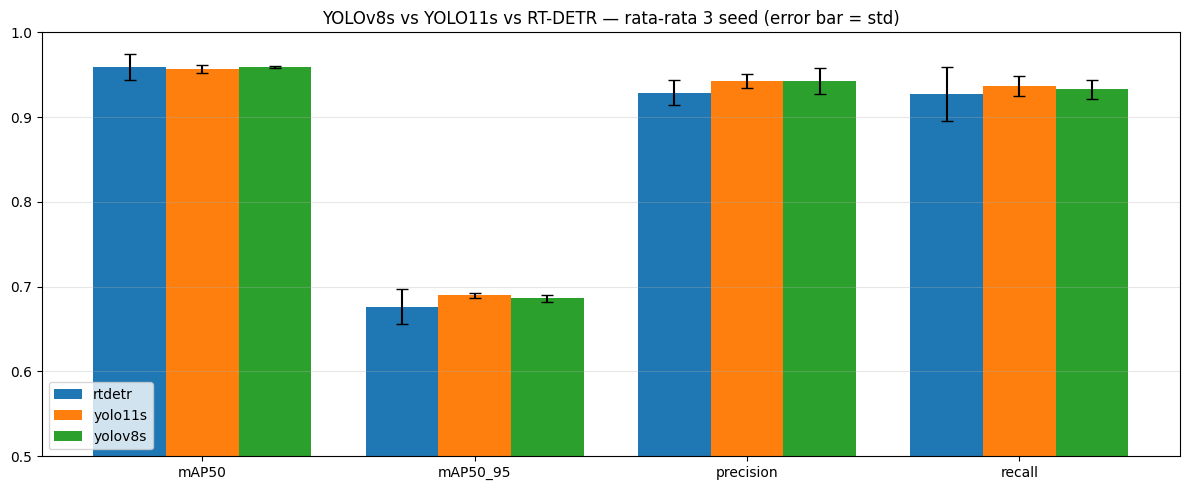

In [6]:
acc = ['mAP50', 'mAP50_95', 'precision', 'recall']
means = df_runs.groupby('model')[acc].mean()
stds = df_runs.groupby('model')[acc].std()

fig, ax = plt.subplots(figsize=(12, 5))
models = list(means.index)
n = len(models); x = np.arange(len(acc)); w = 0.8 / n
for i, model in enumerate(models):
    ax.bar(x + (i - (n - 1) / 2) * w, means.loc[model], w, yerr=stds.loc[model],
           capsize=4, label=model)
ax.set_xticks(x); ax.set_xticklabels(acc); ax.set_ylim(0.5, 1.0)
ax.set_title('YOLOv8s vs YOLO11s vs RT-DETR — rata-rata 3 seed (error bar = std)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Apakah perbedaannya nyata?

In [7]:
import itertools
models = sorted(df_runs.model.unique())
print('Perbandingan pairwise (|selisih mean| vs std antar-seed; indikatif, n kecil):')
for a, b in itertools.combinations(models, 2):
    da, db = df_runs[df_runs.model == a], df_runs[df_runs.model == b]
    print(f'\n{a} vs {b}:')
    for metric in ['mAP50', 'mAP50_95']:
        d = da[metric].mean() - db[metric].mean()
        pooled = (da[metric].std() + db[metric].std()) / 2
        verdict = 'NYATA' if abs(d) > pooled else 'dalam noise (tidak nyata)'
        print(f'  {metric}: Δ={d:+.4f} | std~{pooled:.4f} -> {verdict}')

Perbandingan pairwise (|selisih mean| vs std antar-seed; indikatif, n kecil):

rtdetr vs yolo11s:
  mAP50: Δ=+0.0019 | std~0.0099 -> dalam noise (tidak nyata)
  mAP50_95: Δ=-0.0134 | std~0.0118 -> NYATA

rtdetr vs yolov8s:
  mAP50: Δ=-0.0004 | std~0.0083 -> dalam noise (tidak nyata)
  mAP50_95: Δ=-0.0097 | std~0.0125 -> dalam noise (tidak nyata)

yolo11s vs yolov8s:
  mAP50: Δ=-0.0023 | std~0.0030 -> dalam noise (tidak nyata)
  mAP50_95: Δ=+0.0037 | std~0.0038 -> dalam noise (tidak nyata)


## 7. Kesimpulan

Bandingkan ketiga arsitektur lewat tabel rata-rata ± std (sel 4) dan verdict pairwise (sel 6). Bila selisih mean lebih kecil daripada std antar-seed, model-model itu **setara secara statistik** pada dataset ini — pilih berdasarkan kecepatan (FPS), ukuran, atau kebutuhan deployment. Untuk klaim publikasi: tambah seed (5+), uji-t formal, dan ukur FPS saat GPU idle (FPS di sweep ini bias karena beban GPU).